# Map flood risk area

- Used `monthly-flood-risk-area.csv` data from HII
- It shows the number of flood occurrences for each Tambon/ADM3 in a given calendar month over 17 years (2548-2564).
- Aggregate 12 month: risk level (take max)

1. load + clean
2. data check / join-key check (GEOCODE vs ADM3_PCODE)
3. fix mismatch
4. take max across all months
5. classification 1: high risk only (`high` / `norisk`)
6. classification 2: 4 levels (`norisk` / `low` / `medium` / `high`)
7. maps + output geojson → tableau

## Setup

In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

CSV_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/monthly-flood-risk-area.csv')
SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/tha_admbnda_adm3_rtsd_20220121_geo.json')
OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')

## Cleaning
- rename RISK column to en

In [2]:
RISK_LABELS = {'เสี่ยงต่ำ': 'low', 'เสี่ยงปานกลาง': 'medium', 'เสี่ยงสูง': 'high'}

flood = pd.read_csv(CSV_PATH)
flood['RISK'] = flood['RISK'].map(RISK_LABELS)
flood['CODE'] = flood['GEOCODE'].astype(str)

print('Rows:', len(flood), '\nTambons:', flood['CODE'].nunique(), '\nMonths:', sorted(flood['Month'].unique()))
flood[['Month', 'CODE', 'TAMBON_E', 'AMPHOE_E', 'COUNT 17 YEAR', 'RISK']].head()

Rows: 27023 
Tambons: 6435 
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,Month,CODE,TAMBON_E,AMPHOE_E,COUNT 17 YEAR,RISK
0,1,120501,Sai Noi,Sai Noi District,1,low
1,1,120503,Nong Phrao Ngai,Sai Noi District,1,low
2,1,120504,Sai Yai,Sai Noi District,1,low
3,1,120505,Khun Si,Sai Noi District,1,low
4,1,120507,Thawi Watthana,Sai Noi District,1,low


## Shape Files

In [3]:
shapes = gpd.read_file(SHAPE_PATH)
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')

print('ADM3 count:', shapes['CODE'].nunique())
shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM2_EN', 'ADM1_EN']].head()

ADM3 count: 7425


,ADM3_PCODE,ADM3_EN,ADM2_EN,ADM1_EN
0,TH100101,Phraborom Maharatchawang,Phra Nakhon,Bangkok
1,TH100102,Wang Burapha Phirom,Phra Nakhon,Bangkok
2,TH100103,Wat Ratchabophit,Phra Nakhon,Bangkok
3,TH100104,Samran Rat,Phra Nakhon,Bangkok
4,TH100105,San Chaopho Suea,Phra Nakhon,Bangkok


## Join
- match flood and shapefiles ดูว่าอันไหนหากันไม่เจอ
- assume ว่าตำบลที่ไม่มี risk type ให้เป็น `norisk`

In [4]:
flood_codes = set(flood['CODE'])
shape_codes = set(shapes['CODE'])

only_in_flood = flood_codes - shape_codes
only_in_shapes = shape_codes - flood_codes

print('Matched geocodes:', len(flood_codes & shape_codes))
print('Only in flood:   ', len(only_in_flood), sorted(only_in_flood))
print('Only in shapes:  ', len(only_in_shapes), '(assume -> norisk)')

Matched geocodes: 6433
Only in flood:    2 ['401050', '630191']
Only in shapes:   992 (assume -> norisk)


## Fix Mismatch
- หา area ใกล้ๆ แล้ว map ที่หาไม่เจอเข้าด้วยกัน

In [5]:
def nearest_shape_code(flood_row):
    amphoe = flood_row['AMPHOE_E'].replace(' District', '').strip()
    same_amphoe = shapes.loc[shapes['ADM2_EN'].str.lower() == amphoe.lower(), 'CODE']
    target_last2 = int(flood_row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - target_last2))

orphans = flood[flood['CODE'].isin(only_in_flood)].drop_duplicates('CODE')
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}

print('Re-mapped orphan flood codes to the nearest shape:')
for old, new in remap.items():
    print(f'  {old} -> {new}')

flood['CODE'] = flood['CODE'].replace(remap)

Re-mapped orphan flood codes to the nearest shape:
  630191 -> 630115
  401050 -> 401017


## Take max across all months
- ยุบ 12 เดือน: แต่ละตำบลเก็บ risk level สูงสุดที่เคยเจอ
- ตำบลที่ไม่เจอหรือไม่มี ปัดเป็น `norisk`

In [ ]:
SEVERITY = {'norisk': 0, 'low': 1, 'medium': 2, 'high': 3}
RISK_ORDER = ['norisk', 'low', 'medium', 'high']

max_risk_by_code = (flood
                    .sort_values('RISK', key=lambda s: s.map(SEVERITY))
                    .drop_duplicates('CODE', keep='last')
                    .set_index('CODE')['RISK'])

max_map = shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM3_TH', 'ADM2_EN', 'ADM1_EN', 'CODE', 'geometry']].copy()
max_map['RISK_MAX'] = max_map['CODE'].map(max_risk_by_code).fillna('norisk')

print('Tambons:', len(max_map))
max_map[['ADM3_PCODE', 'ADM3_EN', 'ADM2_EN', 'RISK_MAX']].head()

Tambons: 7425


,ADM3_PCODE,ADM3_EN,ADM2_EN,RISK_MAX
0,TH100101,Phraborom Maharatchawang,Phra Nakhon,low
1,TH100102,Wang Burapha Phirom,Phra Nakhon,low
2,TH100103,Wat Ratchabophit,Phra Nakhon,low
3,TH100104,Samran Rat,Phra Nakhon,low
4,TH100105,San Chaopho Suea,Phra Nakhon,low


## Classification 1 — high risk only
- ดูเฉพาะพื้นที่ high: ตำบลที่ take max ได้ `high` → `high`, ที่เหลือ → `norisk`

In [7]:
max_map['HIGH_ONLY'] = max_map['RISK_MAX'].apply(lambda risk: 'high' if risk == 'high' else 'norisk')

print(max_map['HIGH_ONLY'].value_counts().reindex(['norisk', 'high']).to_string())

HIGH_ONLY
norisk    5980
high      1445


## Classification 2 — 4 levels
- ดู take max data ทั้งหมด แล้วแบ่ง 4 กลุ่ม: `norisk` / `low` / `medium` / `high`

In [8]:
counts = max_map['RISK_MAX'].value_counts().reindex(RISK_ORDER)
percent = (counts / len(max_map) * 100).round(1)

print(pd.DataFrame({'tambons': counts, 'percent': percent}).to_string())

          tambons  percent
RISK_MAX                  
norisk        992     13.4
low          2592     34.9
medium       2396     32.3
high         1445     19.5


## Maps
- โทนเดิม: เทา = norisk → ส้ม → แดง = high
- legend แสดงเฉพาะ level ที่มีจริงใน map

<Axes: title={'center': 'Retro flood risk — high risk (17-year, ADM3)'}>

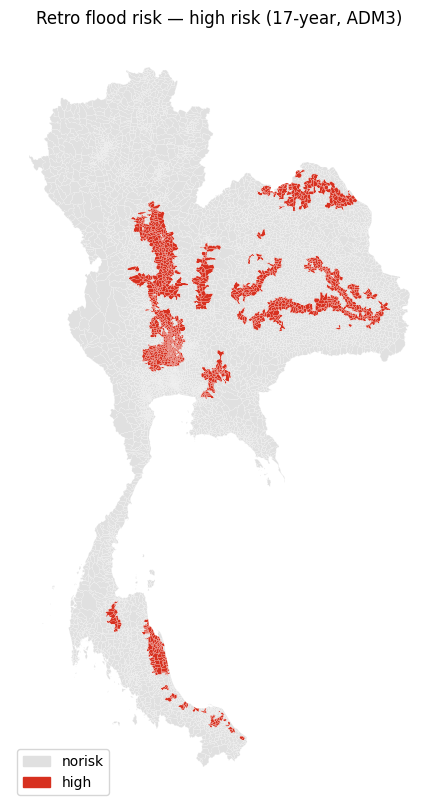

In [11]:
from matplotlib.patches import Patch

RISK_COLORS = {'norisk': '#E0E0E0', 'low': '#FDD49E', 'medium': '#FC8D59', 'high': '#D7301F'}


def plot_risk(column, title):
    levels_in_map = [level for level in RISK_ORDER if level in set(max_map[column])]
    ax = max_map.plot(color=max_map[column].map(RISK_COLORS),
                      figsize=(8, 10), edgecolor='white', linewidth=0.1)
    ax.set_title(title)
    ax.axis('off')
    ax.legend(handles=[Patch(color=RISK_COLORS[level], label=level) for level in levels_in_map],
              loc='lower left')
    return ax


plot_risk('HIGH_ONLY', 'Retro flood risk — high risk (17-year, ADM3)')

<Axes: title={'center': 'Retro flood risk — 17-year, ADM3'}>

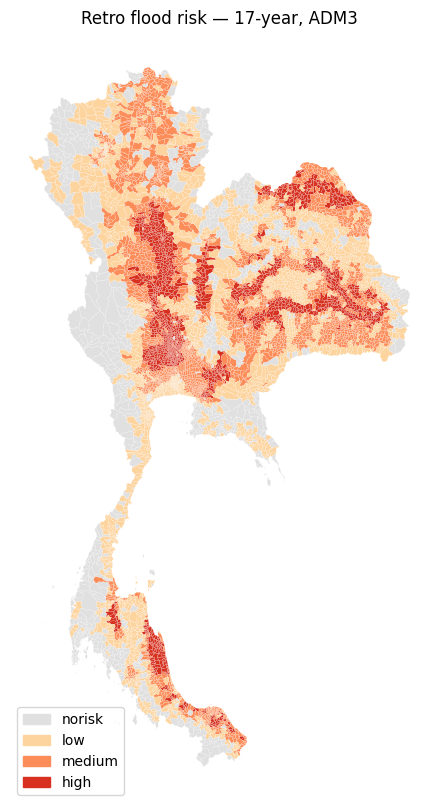

In [10]:
plot_risk('RISK_MAX', 'Retro flood risk — 17-year, ADM3')

## Output
- ไฟล์เดียว รวมทั้ง 2 classification (`HIGH_ONLY`, `RISK_MAX`) → tableau เลือก field เอา

In [11]:
output_file = OUTPUT_PATH / 'retro_max_risk.geojson'
max_map.drop(columns='CODE').to_file(output_file, driver='GeoJSON')

print(f'{output_file.name}: {len(max_map)} features ({output_file.stat().st_size / 1e6:.1f} MB)')

retro_max_risk.geojson: 7425 features (11.2 MB)
